In [381]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Logistic Regression Classification - Titanic Dataset

## Objective

Build a Logistic Regression model to predict whether a passenger survived the Titanic disaster.

### Steps

1. Load the dataset
2. Handle missing values
3. Encode categorical variables
4. Select features
5. Split the dataset
6. Scale the features
7. Train Logistic Regression
8. Evaluate using Confusion Matrix and Classification Report
9. Experiment with threshold tuning
10. Understand Sigmoid and Log Loss

## Load the Dataset

We load the Titanic dataset from Seaborn and inspect the data before preprocessing.

In [382]:
df = sns.load_dataset("titanic")

In [383]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [384]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [385]:
df["age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

## Handle Missing Values

The **Age** column contains missing values.

Since Age may contain outliers, we replace missing values using the **median**, which is more robust than the mean.

In [386]:
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)

In [387]:
df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Encode Categorical Variables

Machine learning models require numerical inputs.

Convert:

- Male → 1
- Female → 0

In [388]:
df["sex"] = df["sex"].replace({"male": 1, "female": 0})

## Feature Selection

Features:

- Sex
- Passenger Class
- Age
- SibSp
- Parch

Target:

- Survived

In [389]:
X = df[["sex", "pclass", "age", "sibsp", "parch"]]
y = df["survived"]

## Train-Test Split

The data is split into training and testing sets.

Training data is used to train the model, while testing data evaluates performance on unseen data.

In [390]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

## Feature Scaling

StandardScaler standardizes numerical features so they have mean 0 and standard deviation 1.

The scaler is fitted only on the training data to avoid data leakage.

In [391]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Train Logistic Regression Model

In [392]:
model = LogisticRegression()

model.fit(x_train, y_train)

LogisticRegression()

## Make Predictions

In [393]:
y_pred = model.predict(x_test)

## Confusion Matrix

The confusion matrix summarizes the prediction results.

- True Positive
- True Negative
- False Positive
- False Negative

In [394]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[89, 16],
       [18, 56]], dtype=int64)

In [395]:
precision = cm[1][1] / (cm[1][1] + cm[0][1])

recall = cm[1][1] / (cm[1][1] + cm[1][0])

f1 = (2 * precision * recall) / (precision + recall)

print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")

Precision : 0.778
Recall    : 0.757
F1 Score  : 0.767


In [396]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



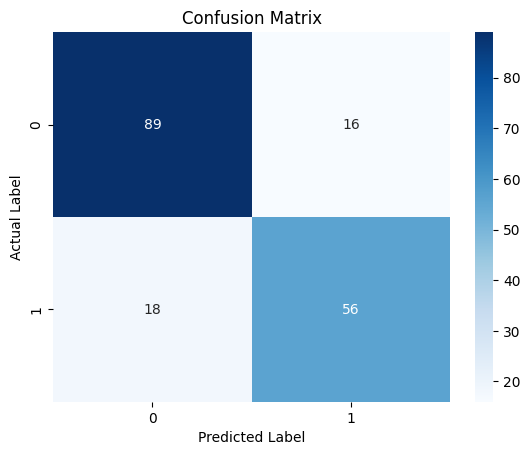

In [397]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## Threshold Tuning

Instead of using the default threshold of 0.5, we lower it to 0.3.

This generally increases Recall while reducing Precision.

In [398]:
probabilities = model.predict_proba(x_test)

probabilities[:5]

array([[0.92267323, 0.07732677],
       [0.75419198, 0.24580802],
       [0.86114242, 0.13885758],
       [0.09263599, 0.90736401],
       [0.3160977 , 0.6839023 ]])

In [399]:
y_pred_03 = (probabilities[:, 1] > 0.3).astype(int)

In [400]:
cm_03 = confusion_matrix(y_test, y_pred_03)

print("Threshold = 0.3")
print(cm_03)

print()

print("Threshold = 0.5")
print(cm)

Threshold = 0.3
[[78 27]
 [10 64]]

Threshold = 0.5
[[89 16]
 [18 56]]


In [401]:
print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81       105
           1       0.70      0.86      0.78        74

    accuracy                           0.79       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.81      0.79      0.79       179



## Manual Sigmoid Calculation

Logistic Regression computes

z = wX + b

Probability is calculated using

P = 1 / (1 + e^(-z))

In [402]:
weights = model.coef_[0]
intercept = model.intercept_[0]

z = 0

for i in range(len(weights)):
    z += weights[i] * x_test[0][i]

z += intercept

probability = np.exp(z) / (1 + np.exp(z))

print("Predicted Probability:", probability)

Predicted Probability: 0.07732677204731837


In [403]:
print("Actual Label:", y_test.iloc[0])

Actual Label: 1


## Manual Log Loss

For an actual label of 0:

Loss = -log(1-p)

For an actual label of 1:

Loss = -log(p)

Lower loss indicates better predictions.

In [404]:
log_loss = -math.log(1 - probability)

print("Log Loss:", log_loss)

Log Loss: 0.08048013971757928


In this notebook we:

- Loaded the Titanic dataset
- Explored missing values
- Filled missing Age values using the median
- Encoded categorical variables
- Selected relevant features
- Split the dataset into train and test sets
- Standardized the features
- Trained a Logistic Regression model
- Evaluated performance using a Confusion Matrix
- Calculated Precision, Recall, and F1 Score manually
- Verified results using `classification_report`
- Visualized the Confusion Matrix
- Tuned the decision threshold from 0.5 to 0.3
- Understood cost-sensitive classification
- Computed the Sigmoid function manually
- Calculated Log Loss manually

This notebook demonstrates both the implementation and mathematical intuition behind Logistic Regression.